# Methane Plume Injection Demo

End-to-end pipeline for injecting synthetic methane plumes into EMIT
imaging-spectrometer radiance scenes and validating the injection with
matched-filter retrieval algorithms (MF, RMF, MAG1C).

**Data** — hosted on HuggingFace: [`tacofoundation/methaneset`](https://huggingface.co/datasets/tacofoundation/methaneset)  
**Code** — hosted on GitHub [`methaneset-codes/injection`](https://github.com/IPL-UV/taco-methaneset/tree/main/methaneset-codes/injection).

In [ ]:
!rm -rf Injection

## 0. Setup

Install dependencies and clone the repository.  
Set `GITHUB_REPO` to the HTTPS URL of your fork or the upstream repo.

In [ ]:
#@title Setup: install dependencies & clone repository

# ── Repository ────────────────────────────────────────────────────────
GITHUB_REPO = "https://github.com/cginerll/Injection"
REPO_BRANCH = "main"
# ──────────────────────────────────────────────────────────────────────

import subprocess, sys, os

# Install Python dependencies
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "rasterio", "tacoreader", "affine", "pyproj",
    "xarray", "netcdf4", "scipy", "pydantic",
    "safetensors", "tqdm",
])

# Clone the repository (skip if already cloned)
REPO_DIR = os.path.basename(GITHUB_REPO.rstrip("/"))
if not os.path.isdir(REPO_DIR):
    subprocess.check_call([
        "git", "clone", "--depth", "1",
        "-b", REPO_BRANCH, GITHUB_REPO, REPO_DIR,
    ])
    print(f"Cloned → {REPO_DIR}/")
else:
    print(f"Repository already present at {REPO_DIR}/")

# Make the repo importable
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

print("Setup complete.")

Cloned → Injection/
Setup complete.


## 1. Configuration

Physical constants, grid definitions, and paths for the
methane plume injection pipeline.

- **Paths**: EMIT scenes and the plume bank on HuggingFace.
- **Patch settings**: size of the radiance patch, number of plumes, emission rate range.
- **Physical constants**: background methane, plume bank pixel resolution, EMIT nodata.
- **Wind settings**: `USE_WIND_FIELD = True` reads wind from the scene's `wind.tif`;
  `False` uses a fixed/random wind for the whole patch.

In [ ]:
from pathlib import Path

# ---------------------------------------------------------------------------
# Paths (HuggingFace)
# ---------------------------------------------------------------------------
DIR_EMIT_SCENES = "https://huggingface.co/datasets/tacofoundation/methaneset/resolve/main/methaneset-emit"
DIR_PLUME_BANK  = "https://huggingface.co/datasets/tacofoundation/methaneset/resolve/main/methaneset-bank"

# Sensor characterisation files (shipped inside the cloned repository)
EMIT_WAVELENGTHS_FILE = Path("emit_wavelengths.npy")
EMIT_FWHM_FILE        = Path("emit_fwhm.npy")

# ---------------------------------------------------------------------------
# Patch & plume settings
# ---------------------------------------------------------------------------
PATCH_H = 128                 # patch height [pixels]
PATCH_W = 128                 # patch width  [pixels]
N_PLUMES = None               # number of plumes (None = random 1-10)
SOURCE = "multi"              # "area" or "multi"
MIN_SEPARATION = 15           # min pixels between sources
MARGIN = 10                   # min pixels from patch edge

Q_MIN_KGH = 100               # minimum emission rate [kg/h]
Q_MAX_KGH = 10000.0           # maximum emission rate [kg/h]
Q_REF_KGH = 3000.0            # plume bank reference rate [kg/h]
Q_TARGET_KGH = None           # rate per plume (None = random Q_MIN–Q_MAX)

# ---------------------------------------------------------------------------
# Wind
# ---------------------------------------------------------------------------
USE_WIND_FIELD = False        # True -> wind.tif per-pixel field
WIND_SPEED = None             # m/s (None = random from bank)
WIND_DIR = None               # deg  (None = random 0-359)

# ---------------------------------------------------------------------------
# Physical constants
# ---------------------------------------------------------------------------
MR_BACKGROUND_PPB = 1900.0    # atmospheric methane concentration
ENHANCEMENT_PIXEL_RES = 20.0  # bank pixel resolution [m]
EMIT_NODATA = -9999.0
CH4_WINDOWS = [(1000, 2500)]  # wavelength ranges for radiance to be modified

## 2. Background patch

Select a plume-free, nodata-free radiance patch from a random EMIT scene.
The scene is tiled into a regular grid, and tiles that overlap real-plume
masks (IMEO + Carbon Mapper, dilated by 5 px ~300 m) or contain EMIT
nodata are discarded.  One of the remaining tiles is chosen at random.

The plot shows the full EMIT scene in RGB with the dilated plume mask (red overlay), the tile grid (yellow) and the selected tile (green).

Patch shape : (285, 128, 128)
Scene ID    : EMIT_L1B_RAD_001_20230326T142844_2308510_039
SZA=49.0°  SAA=241.5°  VZA=7.1°


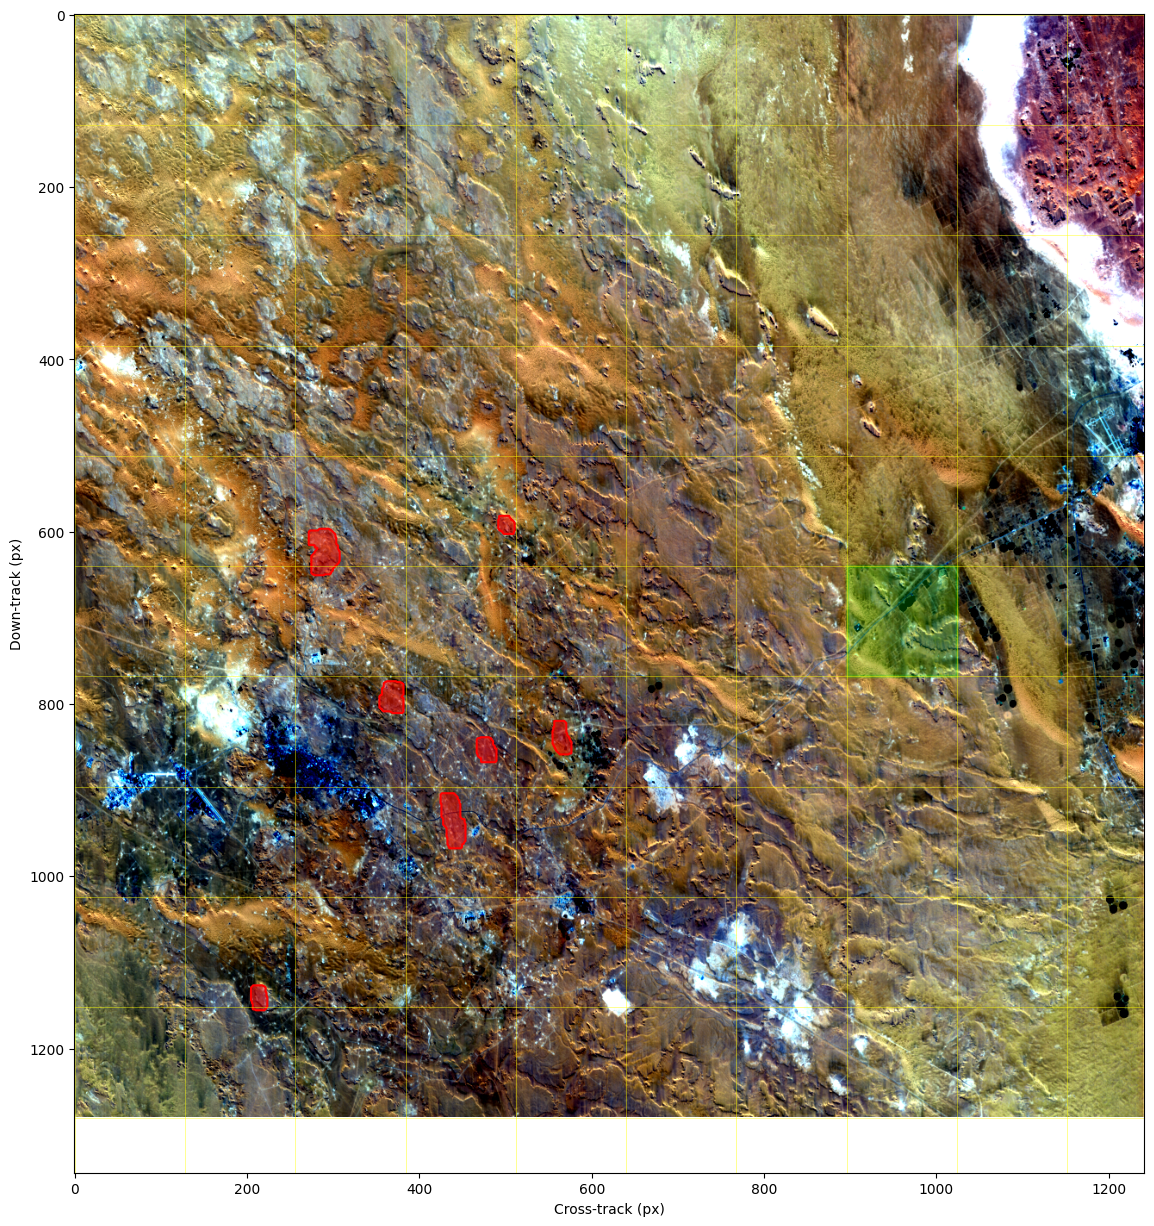

In [ ]:
from emit_bckg import get_emit_background
from viz import plot_scene_overview

import numpy as np
import warnings
from rasterio.errors import NotGeoreferencedWarning
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

# -- Select a plume-free patch from a random EMIT scene -------------
# Tiles the scene into a PATCH_H x PATCH_W grid, discards tiles that overlap
# real-plume masks (IMEO + Carbon Mapper, dilated 5 px) or contain
# EMIT nodata (-9999), and picks one at random.
radiance, scene_row, reading_window, plume_mask = get_emit_background(
    data_dir=DIR_EMIT_SCENES,
    patch_height=PATCH_H,
    patch_width=PATCH_W,
)

# Keep an untouched copy -- we need it later to compare
# original vs. injected spectra (Section 5)
radiance_original = radiance.copy()

# -- Extract scene metadata -------------------------------------------
# GDAL VSI path to the scene directory (for reading lat/lon, wind, etc.)
_vsi = scene_row["internal:gdal_vsi"]
scene_dir = _vsi.rsplit("/", 1)[0]

sza = scene_row["target:sza"]
saa = scene_row["target:saa"]
vza = scene_row["target:vza"]

print(f"Patch shape : {radiance.shape}")
print(f"Scene ID    : {scene_row['id']}")
print(f"SZA={sza:.1f}°  SAA={saa:.1f}°  VZA={vza:.1f}°")

# -- EMIT sensor characterisation -------------------------------------
# Central wavelengths and FWHM for each of the 285 EMIT bands
emit_wvl = np.load(EMIT_WAVELENGTHS_FILE)
emit_fwhm = np.load(EMIT_FWHM_FILE)

# -- Plot the scene ---------------------------------------------------
plot_scene_overview(
    scene_row, reading_window, PATCH_H, PATCH_W, emit_wvl, plume_mask
)

## 3. Emission source positions + Wind conditions + Plume bank query

Generate random positions within the patch for the plume sources.
Each source is placed at least `MARGIN` pixels from the edge and at least
`MIN_SEPARATION` pixels from any other source.  For a single plume, the
source is placed at the centre of the patch.

Resolve wind speed and direction, either from the scene's `wind.tif` field or from a single fixed/random value

Query the plume bank for the closest matching plume(s) given the solar geometry and wind conditions.

5 source(s) placed:
   [1] row= 112, col=  97
   [2] row= 116, col=  22
   [3] row= 109, col= 112
   [4] row=  92, col=  98
   [5] row=  69, col=  12


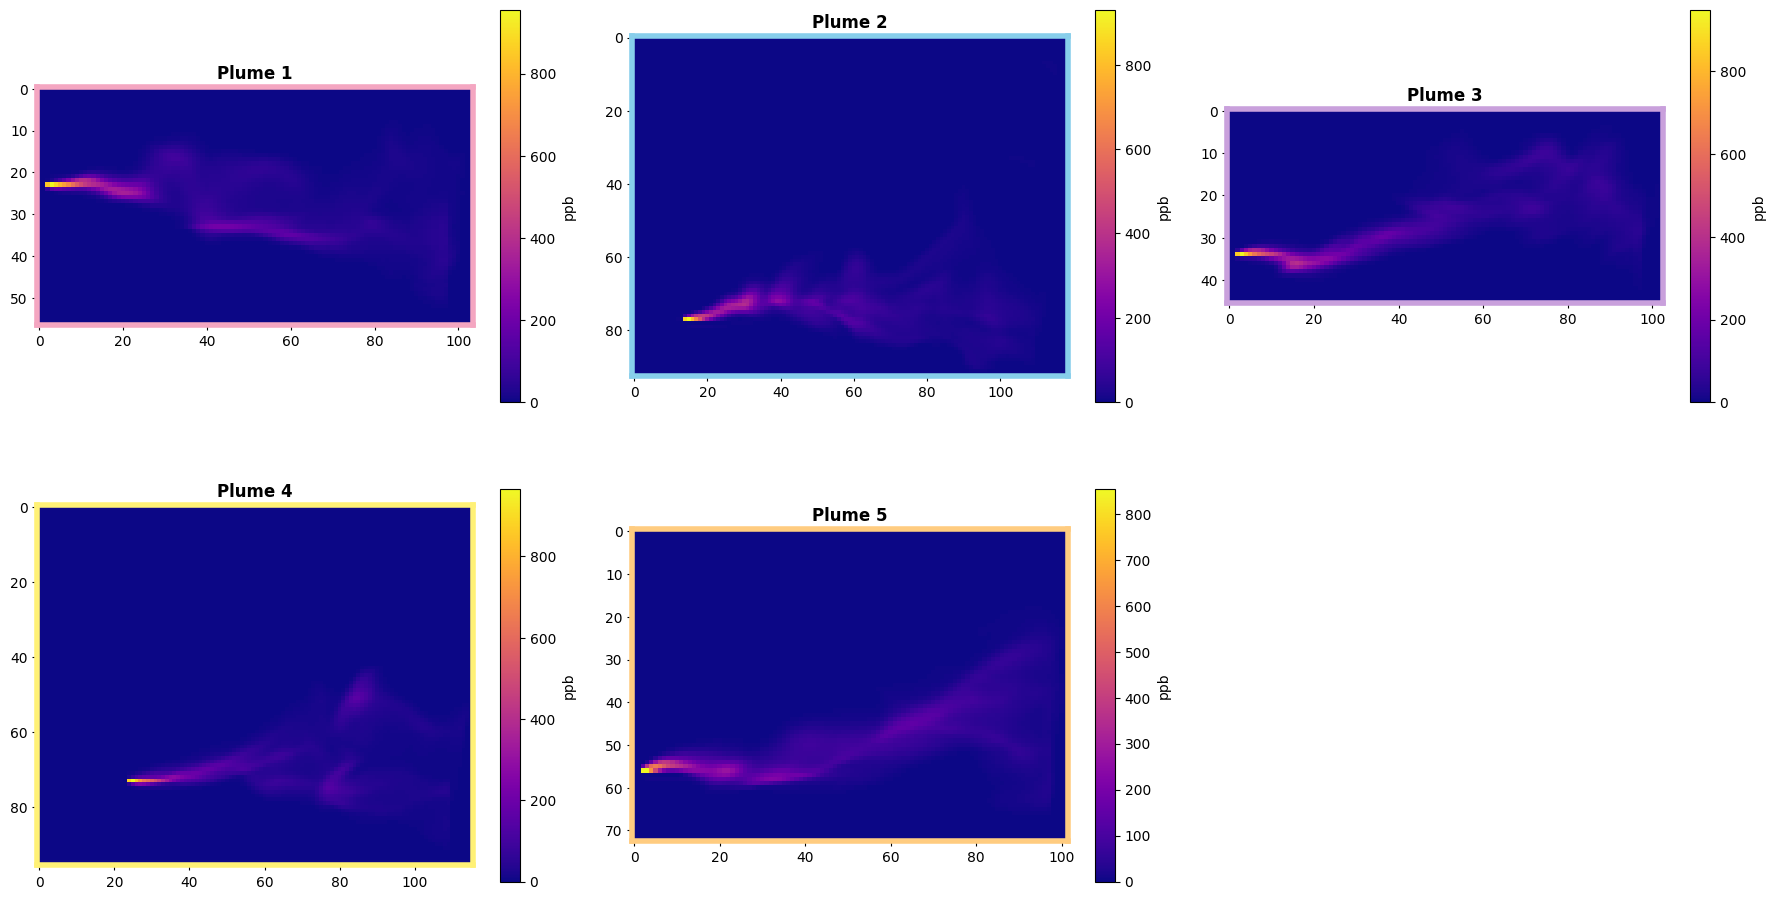

5 plume(s) queried:
   [1] p3_w08.0_s089_sza47.5_raa255.8  type=multi  wind=8.0 m/s @ 314°  RAA=255°
   [2] p1_w08.0_s064_sza47.5_raa255.8  type=multi  wind=8.0 m/s @ 314°  RAA=255°
   [3] p3_w08.0_s070_sza47.5_raa255.8  type=multi  wind=8.0 m/s @ 314°  RAA=255°
   [4] p8_w08.0_s092_sza47.5_raa255.8  type=multi  wind=8.0 m/s @ 314°  RAA=255°
   [5] p3_w08.0_s105_sza47.5_raa255.8  type=multi  wind=8.0 m/s @ 314°  RAA=255°


In [ ]:
from sources import generate_source_positions
from wind import resolve_wind_and_query_bank
from bank import MethaneBank
from viz import plot_bank_plumes

# -- Generate random source positions within the patch ----------------
# Each source sits at least MARGIN px from the edge and
# MIN_SEPARATION px from any other source.
positions = generate_source_positions(
    N_PLUMES, PATCH_H, PATCH_W, MARGIN, MIN_SEPARATION,
)

print(f"{len(positions)} source(s) placed:")
for i, (r, c) in enumerate(positions, 1):
    print(f"   [{i}] row={r:>4d}, col={c:>4d}")

# -- Initialize the plume bank ----------------------------------------
bank = MethaneBank(DIR_PLUME_BANK)

# -- Resolve wind conditions and query the bank -----------------------
# Two modes:
#   USE_WIND_FIELD=True  -> reads per-pixel U/V from wind.tif
#   USE_WIND_FIELD=False -> single speed/direction for all sources
#
# For each source, queries the bank filtering sequentially:
# snap wind_speed to closest grid value, then SZA, then pick
# the closest RAA among the remaining candidates.
metas, w_dirs, w_speeds, raas = resolve_wind_and_query_bank(
    bank=bank,
    scene_dir=scene_dir,
    reading_window=reading_window,
    emit_positions=positions,
    sza_mean=sza,
    saa_mean=saa,
    source_type=SOURCE,
    use_wind_field=USE_WIND_FIELD,
    wind_speed=WIND_SPEED,
    wind_dir=WIND_DIR,
)

plot_bank_plumes(metas, w_speeds, w_dirs, raas)

print(f"{len(metas)} plume(s) queried:")
for i, (m, ws, wd, raa) in enumerate(zip(metas, w_speeds, w_dirs, raas), 1):
    print(f"   [{i}] {m['id']}  type={m['sim_type']}  "
          f"wind={ws:.1f} m/s @ {wd:.0f}°  RAA={raa:.0f}°")



## 4. Project enhancement maps onto EMIT coordinates

Read the lat/lon grids for the selected patch and project each bank
enhancement map onto the EMIT pixel geometry via footprint integration.

The reprojection is done at Q_ref (3 000 kg/h); the scaling to Q_target
is applied afterwards.  This allows computing the binary plume mask at
reference conditions independently of the emission rate.

Projection complete:
   Peak enhancement: 770 ppb
   [1] Q = 6042 kg/h
   [2] Q = 3765 kg/h
   [3] Q = 5983 kg/h
   [4] Q = 4225 kg/h
   [5] Q = 3605 kg/h


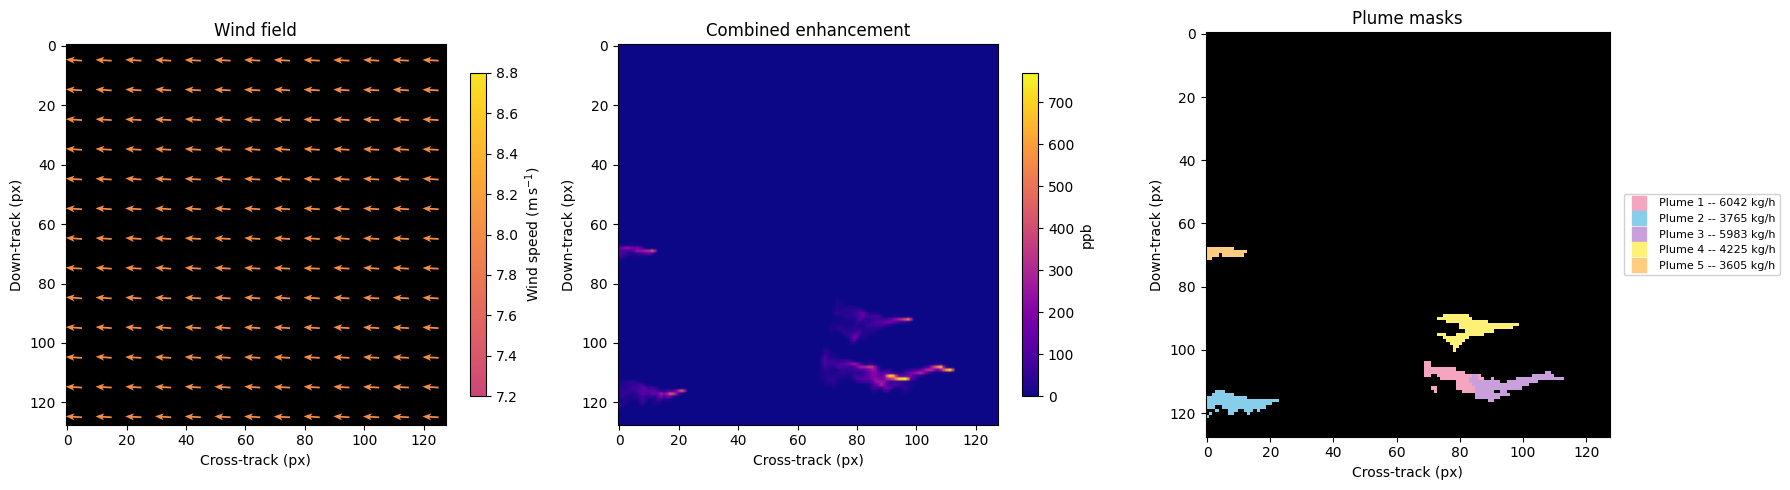

In [ ]:
import rasterio
from project import project_plumes
from viz import plot_enhancement_summary

# Read patch coordinates
with rasterio.open(f"{scene_dir}/latlon.tif") as src:
    emit_lat = src.read(1, window=reading_window)
    emit_lon = src.read(2, window=reading_window)

# -- Project bank enhancements onto EMIT pixel geometry ---------------
# Each bank plume lives on a regular 20 m grid. EMIT pixels are
# irregular ~60 m quadrilaterals. map_to_emit() reprojects via
# footprint integration: for each EMIT pixel, sample NxN points
# inside its real footprint and average the bank enhancement values.
#
# Projection is done at the reference rate Q_REF (3000 kg/h);
# scaling to the target Q is applied afterwards.
enhancement_total, enhancements_ref, plume_raws, q_targets = project_plumes(
    plume_metas=metas,
    emit_positions=positions,
    wind_dirs=w_dirs,
    emit_lat=emit_lat,
    emit_lon=emit_lon,
    q_target_fixed=Q_TARGET_KGH,
)

print(f"Projection complete:")
print(f"   Peak enhancement: {enhancement_total.max():.0f} ppb")
for i, q in enumerate(q_targets, 1):
    print(f"   [{i}] Q = {q:.0f} kg/h")

plot_enhancement_summary(
    enhancement_total, enhancements_ref, q_targets,
    w_speeds, w_dirs, emit_lat, emit_lon,
    PATCH_H, PATCH_W,
    use_wind_field=USE_WIND_FIELD,
    fixed_wind_speed=WIND_SPEED,
    fixed_wind_dir=WIND_DIR,
)

## 5. Spectral injection

Inject the methane plume into the EMIT radiance cube.  The radiance at each
pixel is scaled by the ratio T(mr_bckg + Δ) / T(mr_bckg), where T is the
atmospheric transmittance from the pre-computed LUT, convolved to EMIT band
resolution via a Gaussian Spectral Response Function (SRF).

CH4 bands: 201 (1007-2493 nm)
AMF = 2.531
Injection complete.


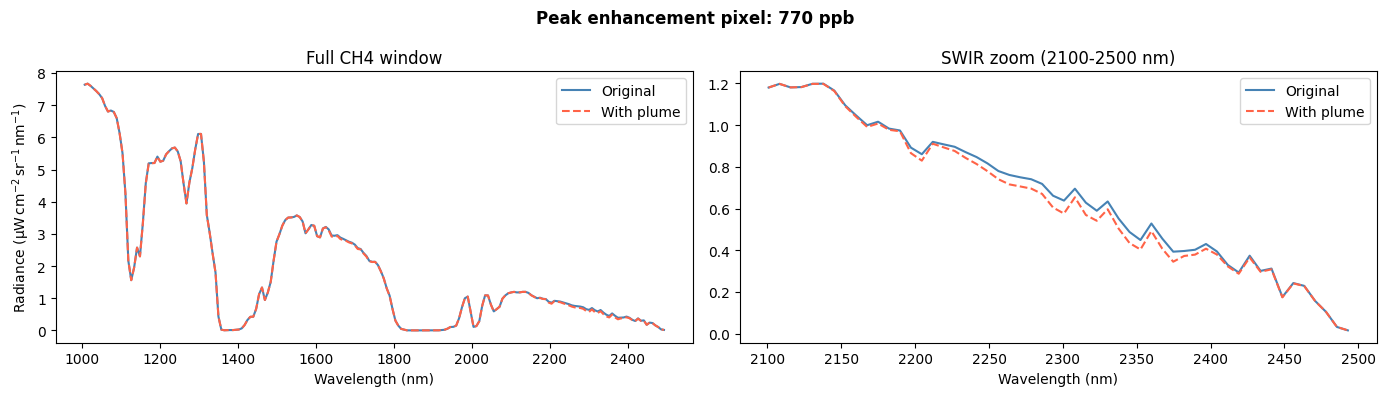

In [ ]:
from pipeline import run_injection
from viz import plot_spectral_comparison

# -- Inject the methane plume into EMIT radiance ----------------------
# For each pixel with enhancement > 0:
#   1. Look up transmittance T(mr) from the pre-computed LUT,
#      interpolated to the scene's Air Mass Factor (AMF)
#   2. Compute the ratio T(mr_background + Delta) / T(mr_background)
#      at LUT spectral resolution
#   3. Convolve to EMIT band resolution via Gaussian SRF
#   4. Multiply the original radiance by this factor
#
# This modifies `radiance` in-place.
radiance_modified = run_injection(
    radiance=radiance,
    enhancement=enhancement_total,
    emit_wvl=emit_wvl,
    emit_fwhm=emit_fwhm,
    sza=sza,
    vza=vza,
)

# -- Compare spectra at the peak enhancement pixel --------------------
plot_spectral_comparison(
    radiance_original, radiance_modified, enhancement_total, emit_wvl
)

## 6. Methane retrieval

Run matched-filter retrieval algorithms (MF, RMF, MAG1C) on the modified
scene.

  Loaded mf.tif from dataset
  Loaded rmf.tif from dataset
  Loaded mag1c.tif from dataset
Download complete.
  Device: cpu
  Running MF... done.
  Running RMF... done.
  Running MAG1C... done.
Retrieval complete.


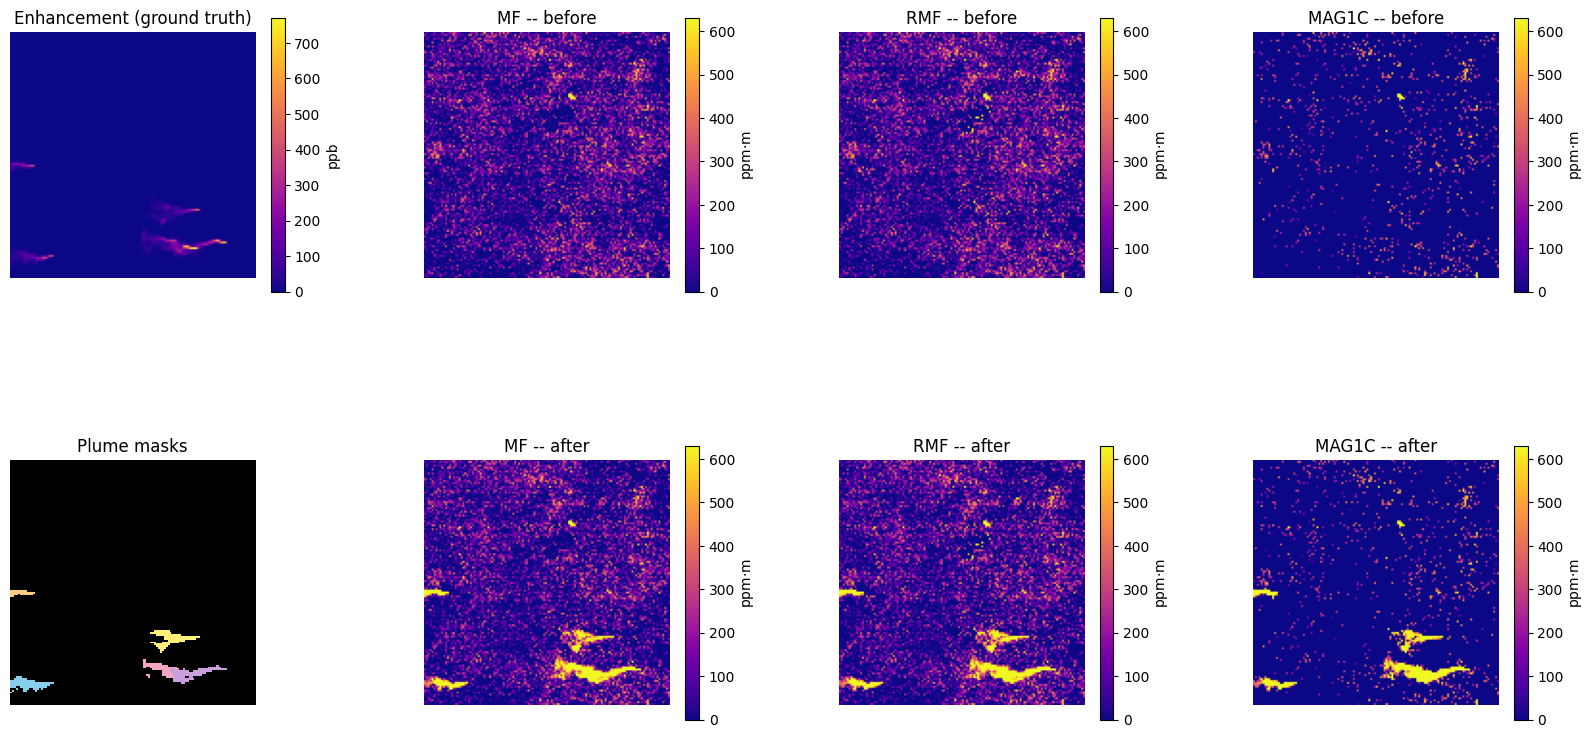

In [ ]:
from retrieval import load_original_retrievals, run_retrievals
from viz import plot_retrieval_comparison

# -- Load pre-existing retrievals from the dataset --------------------
# These are the retrieval maps computed on the ORIGINAL scene
# (without injected plume) -- used as the "before" baseline.
method_names = ["mf", "rmf", "mag1c"]
original_retrievals = load_original_retrievals(
    scene_dir, reading_window, method_names
)

for name, arr in original_retrievals.items():
    print(f"  Loaded {name}.tif from dataset")

# -- Run retrieval on the modified radiance ---------------------------
# Reads the full column of radiance (all downtrack rows for the
# selected crosstrack columns), inserts the modified patch, and
# runs MF / RMF / MAG1C.
# The covariance is estimated from the full column, not just the patch.
modified_retrievals = run_retrievals(
    radiance_modified=radiance_modified,
    scene_dir=scene_dir,
    reading_window=reading_window,
    emit_wvl=emit_wvl,
    patch_h=PATCH_H,
    patch_w=PATCH_W,
    # device="cpu"
)

# -- Compare: ground truth enhancement vs. retrieval before/after -----
plot_retrieval_comparison(
    enhancement_total, enhancements_ref,
    original_retrievals, modified_retrievals,
    PATCH_H, PATCH_W,
)